In [181]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text

In [182]:
csv_files = sorted(Path(".").glob("results*.csv"))
if not csv_files:
    raise FileNotFoundError("Nebyl nalezen zadny soubor results*.csv")

frames = []
for csv_file in csv_files:
    part = pd.read_csv(csv_file)
    part["source_file"] = csv_file.name
    depth_match = re.search(r"d(\d+)", csv_file.stem)
    frames.append(part)

df = pd.concat(frames, ignore_index=True)
depth_label = df["max_depth"].apply(lambda d: f"d={d}" if pd.notna(d) else "")
df["solver_label"] = df["solver"] + depth_label.apply(lambda x: f" ({x})" if x else "")

df


,solver,max_depth,games,best_score,worst_score,avg_score,wins,losses,avg_max_tile,avg_moves_total,avg_moves_up,avg_moves_down,avg_moves_left,avg_moves_right,total_moves,source_file,solver_label
0,random,NaN,100,2824,292,1140.76,0,100,110.40,121.73,38.12,30.47,24.52,28.62,12173,results-d1.csv,random
1,priority_corner,NaN,100,5920,628,2458.48,0,100,195.84,219.43,10.51,54.85,153.92,0.15,21943,results-d1.csv,priority_corner
2,alpha_beta,1.0,100,11356,724,3687.84,0,100,266.24,292.66,1.69,153.56,71.46,65.95,29266,results-d1.csv,alpha_beta (d=1.0)
3,expectiminimax,1.0,100,11816,840,3609.60,0,100,261.76,288.73,1.52,148.29,70.86,68.06,28873,results-d1.csv,expectiminimax (d=1.0)
4,random,NaN,100,2980,212,1170.60,0,100,115.20,122.62,29.53,33.48,28.47,31.14,12262,results-d2.csv,random
5,priority_corner,NaN,100,6888,544,2583.00,0,100,204.16,227.50,10.76,57.02,159.57,0.15,22750,results-d2.csv,priority_corner
6,alpha_beta,2.0,100,24196,3072,13267.00,19,81,1013.76,768.12,5.61,342.14,214.71,205.66,76812,results-d2.csv,alpha_beta (d=2.0)
7,expectiminimax,2.0,100,24268,3328,13098.52,24,76,1062.40,746.66,6.46,332.28,201.91,206.01,74666,results-d2.csv,expectiminimax (d=2.0)
8,random,NaN,100,2692,312,1119.08,0,100,109.44,120.04,27.12,32.93,28.50,31.49,12004,results-d3.csv,random
9,priority_corner,NaN,100,5500,560,2429.88,0,100,193.60,217.71,10.31,54.05,153.25,0.10,21771,results-d3.csv,priority_corner


In [183]:
summary_cols = [
    "source_file",
    "solver",
    "max_depth",
    "games",
    "avg_score",
    "best_score",
    "worst_score",
    "wins",
    "losses",
    "avg_max_tile",
]
df[summary_cols].sort_values(["max_depth", "avg_score"], ascending=[True, False])
df = df.drop_duplicates(subset=["solver_label"])


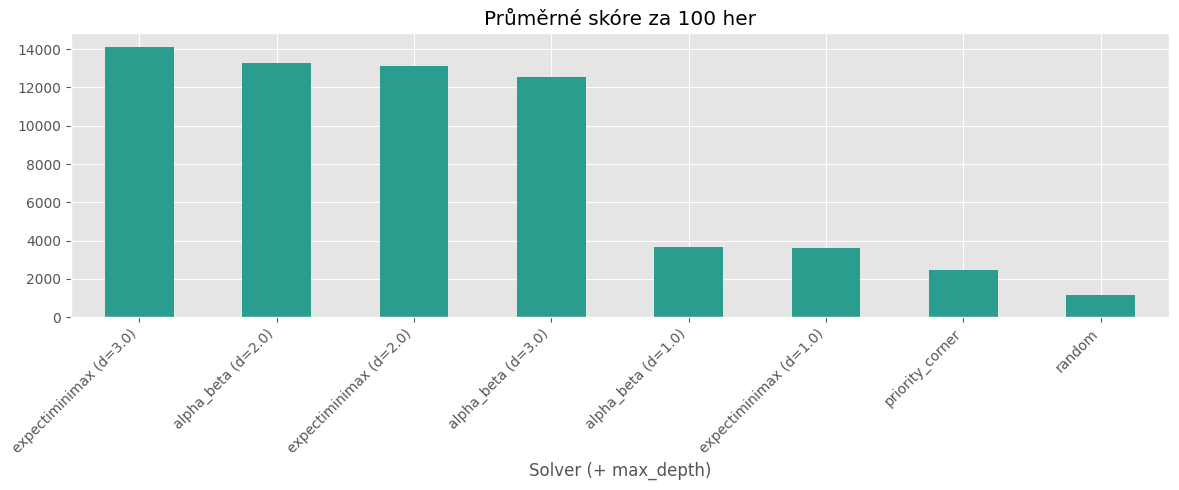

In [184]:
ax = df.sort_values("avg_score", ascending=False).plot(
    kind="bar", x="solver_label", y="avg_score", legend=False, figsize=(12, 5), color="#2a9d8f"
)
ax.set_title("Průměrné skóre za 100 her")
ax.set_xlabel("Solver (+ max_depth)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


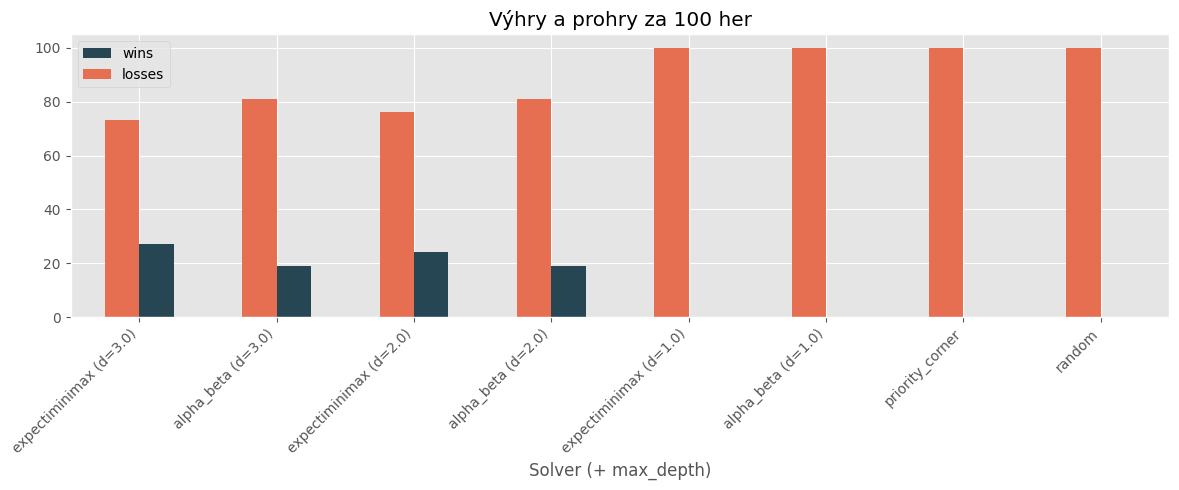

In [185]:
ax = df.set_index("solver_label")[["wins", "losses"]].plot(
    kind="bar", figsize=(12, 5), color=["#264653", "#e76f51"]
)
ax.invert_xaxis()
ax.set_title("Výhry a prohry za 100 her")
ax.set_xlabel("Solver (+ max_depth)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


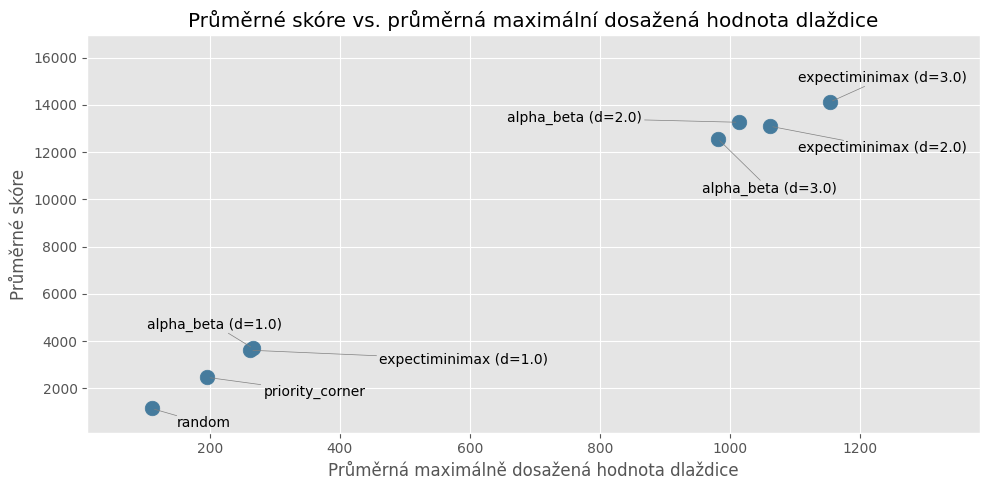

In [186]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["avg_max_tile"], df["avg_score"], s=110, c="#457b9d")

texts = []

for _, row in df.iterrows():
    depth_part = f" d={row['max_depth']}" if pd.notna(row["max_depth"]) else ""
    label = f"{row['solver_label']}"
    t = ax.text(row["avg_max_tile"], row["avg_score"], label)
    texts.append(t)

ax.set_title("Průměrné skóre vs. průměrná maximální dosažená hodnota dlaždice")
ax.set_xlabel("Průměrná maximálně dosažená hodnota dlaždice")
ax.set_ylabel("Průměrné skóre")

ax.set_xlim(right=df["avg_max_tile"].max() * 1.2, left=df["avg_max_tile"].min() * 0.1)
ax.set_ylim(top=df["avg_score"].max() * 1.2, bottom=df["avg_score"].min() * 0.1)

ax.margins(x=0.15, y=0.15)

adjust_text(texts,
            arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
            expand=(2, 2))

plt.tight_layout()
plt.show()